# 📝 Amazon checkout redesign: Impact Analysis

## 🌟 Highlights
From this project "Amazon checkout redesign: Impact Analysis", the highlights are addressed as:
### Conclusion summary
- Lift analysis: 6.386% relative lift at started_checkout and 14.839% relative lift at purchased
- Funnel analysis: Modified checkout process affects customer behavior at started_checkout (1.3% delta) and purchased step (1.4% delta)
- Revenue analysis:
  - Significant difference in order value with 95% confidence level
  - Higher distribution of order value at 30~60 region at treatement group
  - Considering customers who order, lift of order value by group is 13.35%
- Segment analysis
  - No strong dependency between categorical factors and target columns with 95% confidence level and Camer's V analysis
- Conversion analysis: Significant difference at started_checkout and purchased with 95% confidence

### Final busincess decision
- Observed siginificant improvement in lift and conversion rate gain. As a result, it reflects at the significant revenue gain
- Based on pov of significant gain above, suggest to roll out the modified checkout process
- Other open questions might affect final business decision
  - Man power perspective. How much resource is needed to roll out the process ?
  - Cost perspective. How much is the cost to roll out the process 

## ℹ️ Project Introduction
In this Amazon e-commerse system, company currently has the orginal checkout process for a long time. Company is now considering another modified version of checkout process and wondering whether the new checkout process is better than orginal checkout process in terms of conversion rate and revenue gain. In order to judge the result statistically instead of blindly, A/B test is commonly used methodology to make decision in "data driven approach".

## 🎯 Mission & Goal
Given by the csv file including many information, such as grouping, user information, and the corresponding behavior at purchase journey, I need to use statistical approach (A/B testing in this case) to jduge whether modified version of checkout process is statistically better than orginal process. As a result, decision should be made to suggest or not suggest this change and the reason behind.  
**Disclaimer: the used data in this project is synthetic data created by ChatGPT (GPT-5.5)**

## 🏭 Project structure
- Import libraries
- Data inspection & Data cleaning
- EDA
- Lift analysis
- Funnel analysis
- Revenue analysis (t test)
- Segment analysis (chi square test)
- Conversion rate analysis (z test)
- Final business decision

## Import libraries

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import scipy.stats as stats
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

# Show all detail in column
pd.set_option("display.max_colwidth", None)


## Data inspection & Data cleaning

In [105]:
df = pd.read_csv('custom_amazon_checkout_ab_test.csv')

In [106]:
df.head()

,user_id,visit_date,experiment_group,device,traffic_source,customer_type,country,added_to_cart,started_checkout,purchased,order_value
0,1,2026-04-21,control,mobile,organic,new,US,0,0,0,0.0
1,2,2026-04-10,treatment,mobile,paid_search,new,UK,0,0,0,0.0
2,3,2026-04-02,treatment,mobile,email,returning,CA,1,1,0,0.0
3,4,2026-04-10,treatment,mobile,organic,returning,US,0,0,0,0.0
4,5,2026-04-24,control,mobile,email,returning,US,0,0,0,0.0


In [107]:
dictionary = pd.read_csv('custom_amazon_checkout_ab_test_data_dictionary.csv')
dictionary

,column,meaning,how_to_use
0,user_id,Unique visitor ID,Count users
1,visit_date,Date of user visit,Daily trend analysis
2,experiment_group,"A/B test group: control = old checkout, treatment = simplified checkout",Main comparison variable
3,device,Device used by visitor,Segment analysis
4,traffic_source,Marketing source that brought the visitor,Segment analysis
5,customer_type,Whether the visitor is new or returning,Segment analysis
6,country,Visitor country,Segment analysis
7,added_to_cart,"1 if visitor added item to cart, else 0",Funnel metric
8,started_checkout,"1 if visitor started checkout, else 0",Funnel metric
9,purchased,"1 if visitor completed purchase, else 0",Main conversion metric


In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   user_id           120000 non-null  int64  
 1   visit_date        120000 non-null  object 
 2   experiment_group  120000 non-null  object 
 3   device            120000 non-null  object 
 4   traffic_source    120000 non-null  object 
 5   customer_type     120000 non-null  object 
 6   country           120000 non-null  object 
 7   added_to_cart     120000 non-null  int64  
 8   started_checkout  120000 non-null  int64  
 9   purchased         120000 non-null  int64  
 10  order_value       120000 non-null  float64
dtypes: float64(1), int64(4), object(6)
memory usage: 10.1+ MB


In [109]:
# Change visit_date to datetime datatype
df['visit_date'] = pd.to_datetime(df['visit_date'])

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   user_id           120000 non-null  int64         
 1   visit_date        120000 non-null  datetime64[ns]
 2   experiment_group  120000 non-null  object        
 3   device            120000 non-null  object        
 4   traffic_source    120000 non-null  object        
 5   customer_type     120000 non-null  object        
 6   country           120000 non-null  object        
 7   added_to_cart     120000 non-null  int64         
 8   started_checkout  120000 non-null  int64         
 9   purchased         120000 non-null  int64         
 10  order_value       120000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 10.1+ MB


In [111]:
# Check if there is missing data
df.isna().value_counts()

user_id  visit_date  experiment_group  device  traffic_source  customer_type  country  added_to_cart  started_checkout  purchased  order_value
False    False       False             False   False           False          False    False          False             False      False          120000
dtype: int64

Nice. There is no missing value.

In [112]:
# Check whether userid has duplicate
print(f"Unique user ID count: {len(df['user_id'].unique())}")
print(f'Total row count: {df.shape[0]}')

Unique user ID count: 120000
Total row count: 120000


In [113]:
# Calculate returning rate
return_num = df['customer_type'].value_counts()[0]
returning_rate = return_num / df.shape[0]
print(f'Returning rate = {returning_rate:.3f}')

Returning rate = 0.581


In [114]:
# Check the experiement window
print(f"Experiment window: {df['visit_date'].min()} ~ {df['visit_date'].max()}")

Experiment window: 2026-04-01 00:00:00 ~ 2026-04-28 00:00:00


- All the userids are unique
- 58% of users return to the web and 42% of users are new
- System keeps the permanent user id and aggregate the behavior during the experiment window (1 month)

In [115]:
# Check device content
df['device'].value_counts()

mobile     81513
desktop    29931
tablet      8556
Name: device, dtype: int64

Devise usage: mobile > desktop > tablet

In [116]:
# Check traffic source content
df['traffic_source'].value_counts()

organic        38519
paid_search    29819
email          19337
social         17974
direct         14351
Name: traffic_source, dtype: int64

**Meaning of each terms**
- organic: User came naturally without paid advertising. E.g. Google search → user searches “Nike running shoes” and clicks your website
- paid_search: User came from paid ads on search engines. E.g. Google Ads → sponsored result appears when searching “buy laptop”
- email: User came through email marketing campaigns. E.g. Company sends promotional email → user clicks “20% off today” link
- social: User came from social media platforms. E.g. User clicks product link from Instagram, Facebook, TikTok, X
- direct: User entered website directly without referral source. E.g. User types Amazon.com manually, uses bookmark, or app opens website

Major source of visitors: google search key words (organic) and google ads pop-up (paid_search)

## EDA - Business questions to answer
- How many users are from control group and treatment group?
- What country comes more to the web and with which device for each experiment group?
- Bias analysis: What is the distribution of device, traffic source, customer type, and country for each experiment group?
- Does checkout change result in more added_to_cart, started_checkout, and purchased?
- Do returning users tend to proceed further in general?
- What is the major sources of returning users?
- What is the sum of order value from each experiment group in average?

In [117]:
# How many users are from control group and treatment group?
df['experiment_group'].value_counts()

treatment    60112
control      59888
Name: experiment_group, dtype: int64

Around 50% for control and treatment group

In [118]:
# What country comes more to the web and with which device for each experiment group?
df_exp_country = df.groupby(['experiment_group', 'country'])['device'].value_counts().reset_index(name='count')
df_exp_country.head()

,experiment_group,country,device,count
0,control,AU,mobile,4029
1,control,AU,desktop,1573
2,control,AU,tablet,402
3,control,CA,mobile,6204
4,control,CA,desktop,2235


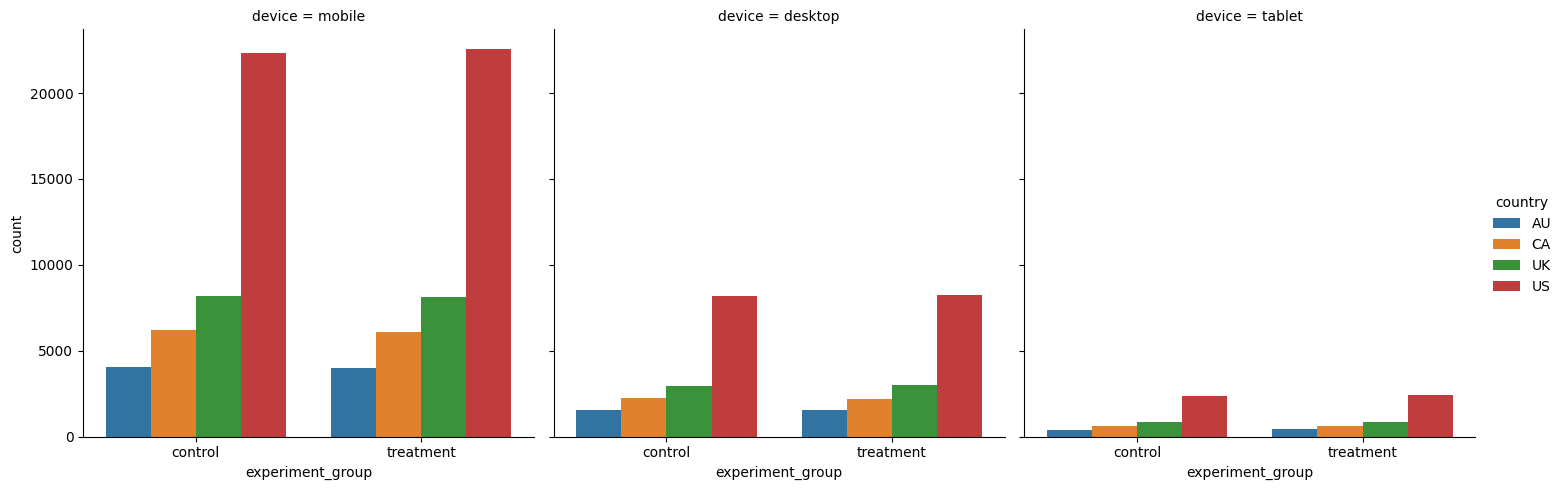

In [119]:
sns.catplot(data=df_exp_country,
            x='experiment_group',
            y='count',
            hue='country',
            col='device',
            kind='bar',
            errorbar=None
           )

plt.show()

In [120]:
df['country'].value_counts()

US    66158
UK    23908
CA    17943
AU    11991
Name: country, dtype: int64

- Majority(>50%) of users are from US
- Each experiment group has similar distribution for each device --> There is no bias for control and treatment group per device
- Usage: mobile > desktop > tablet for both control and treatment group

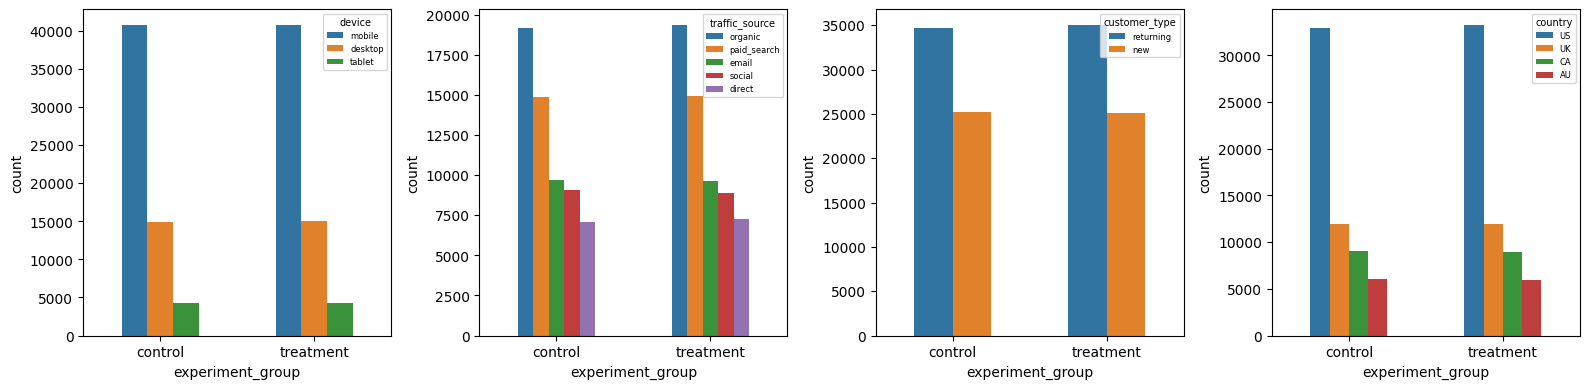

In [121]:
# Bias analysis: What is the distribution of device, traffic source, customer type, and country for each experiment group?
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, c in enumerate(['device', 'traffic_source', 'customer_type', 'country']):
    dff = df.groupby('experiment_group')[c].value_counts().reset_index(name='count')
    sns.barplot(data=dff,
                x='experiment_group',
                y='count',
                hue=c,
                ax=axes[i],width=0.5
               )
    axes[i].legend(title=c, title_fontsize=7, fontsize=6)
plt.tight_layout()
plt.show()

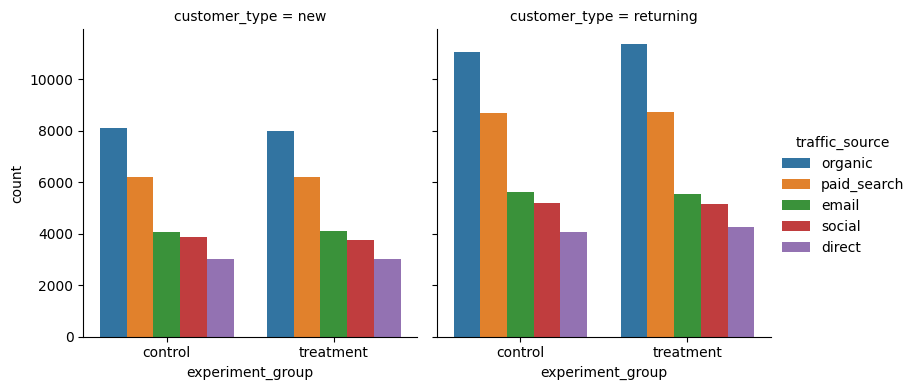

In [122]:
# Check which traffic_source returning group use to revisit the web 
df_exp_cust = df.groupby(['experiment_group', 'customer_type'])['traffic_source'].value_counts().reset_index(name='count')
sns.catplot(data=df_exp_cust,
            x='experiment_group',
            y='count',
            hue='traffic_source',
            col='customer_type',
            kind='bar',
            errorbar=None,
            height=4,
            weights=5
           )
plt.show()

- The distribution of device, traffic_source, customer_type, and country is similar between control and treatment group
- device: mobile > desktop > tablet --> Indicate mobile is the most convenient approach to the web 
- traffic_source: organic > paid_search > email > social > direct --> People tend to use organic (search engine) as the entry point of web
- customer_type: returning > new --> Although it is returning group, people use organic (search engine) as entry not direct method. 
- country: US > UK > CA > AU --> Maybe it indicates the website popularity in certain region

  experiment_group      rate
0          control  0.344777
1        treatment  0.344923
  experiment_group      rate
0          control  0.209207
1        treatment  0.222568
  experiment_group      rate
0          control  0.093942
1        treatment  0.107882


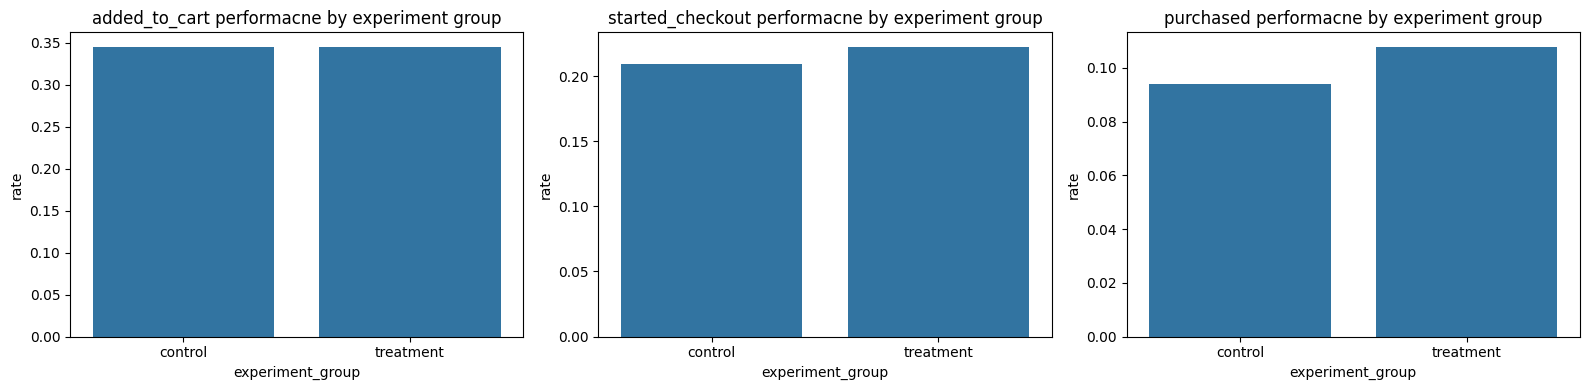

In [123]:
# Does checkout change result in more add_to_cart, started_checkout, and purchase?
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, c in enumerate(['added_to_cart', 'started_checkout', 'purchased']):
    dff = df.groupby('experiment_group')[c].mean().reset_index(name='rate')
    print(dff)
    sns.barplot(data=dff,
                x='experiment_group',
                y='rate',
                errorbar=None,
                ax=axes[i],
               )
    axes[i].set_title(f'{c} performacne by experiment group')
plt.tight_layout()
plt.show()

- No big delta for added_to_cart performance between control group and treatment group
- started_checkout and purchased both show slightly higher count in treatment group --> To check if the difference is statistically significant

  customer_type  average count
0           new       0.308402
1     returning       0.371175
  customer_type  average count
0           new       0.192870
1     returning       0.232533
  customer_type  average count
0           new        0.08332
1     returning        0.11364


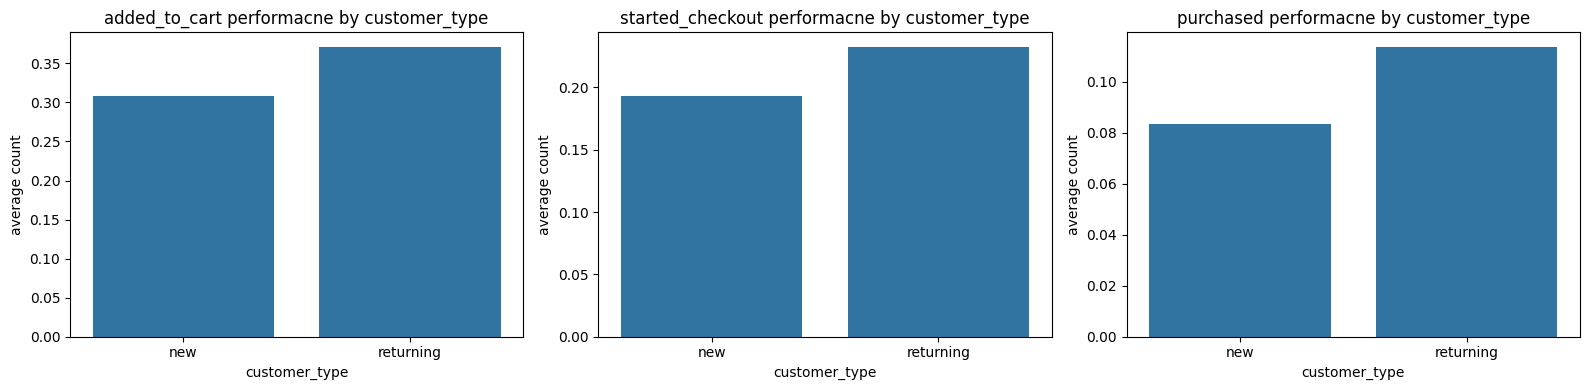

In [124]:
# Do returning users tend to proceed further in general?
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, c in enumerate(['added_to_cart', 'started_checkout', 'purchased']):
    dff = df.groupby('customer_type')[c].mean().reset_index(name='average count')
    print(dff)
    sns.barplot(data=dff,
                x='customer_type',
                y='average count',
                errorbar=None,
                ax=axes[i]
               )
    axes[i].set_title(f'{c} performacne by customer_type')
plt.tight_layout()
plt.show()

Notice that returning group has higher percentage to proceed further (add to cart --> start checkout --> purchase)

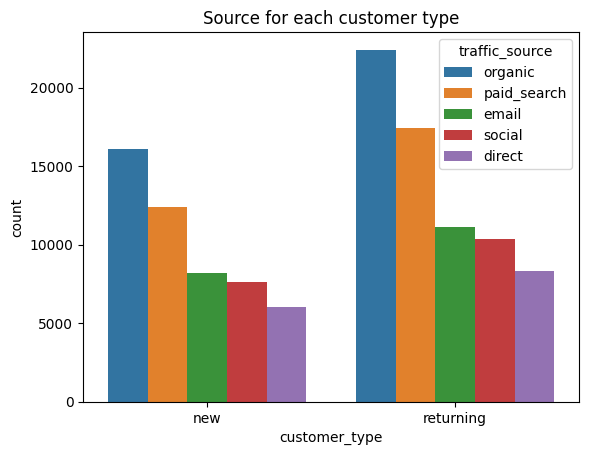

In [125]:
# What is the major sources of returning users?
df_cust = df.groupby('customer_type')['traffic_source'].value_counts().reset_index(name='count')
sns.barplot(data=df_cust,
            x='customer_type',
            y='count',
            hue='traffic_source',
            errorbar=None,
           )
plt.title('Source for each customer type')
plt.show()

Major source of returning group is from organic (search in engine)

  experiment_group  average order value
0          control             4.725882
1        treatment             5.336814


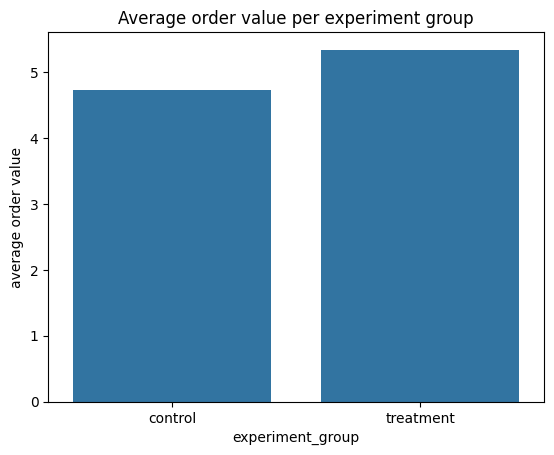

In [126]:
# What is the sum of order value from each experiment group in average?
dff = df.groupby('experiment_group')['order_value'].mean().reset_index(name='average order value')
print(dff)
sns.barplot(data=dff,
            x='experiment_group',
            y='average order value',
            errorbar=None
           )
plt.title('Average order value per experiment group')
plt.show()

treatment group and control group has 5.3 and 4.7 respectively for average order value

**EDA conclusion**
- Population: control group ~ treatment group
- Majority of users are from US
- Device usage: Mobile > desktop > tablet
- Control and treatment group have the similar composition in terms of device, traffic source, customer type, and country. No bias
- Returning group show majority entry source as organic
- Treatment group shows relatively higher ratio in started_checkout (22.5% > 20.9%) and purchased (10.7% > 9.3%)
- Returning group shows relatively higher added_to_cart (37.1% > 30.8%), started_checkout (23.2% > 19.2%) ,and purchased (11.3% > 8.3%)
- Treatment group has relatively higher average order value (5.3 > 4.7)

## Lift analysis
Understand how much the purchase rate changes with new checkout 

In [127]:
steps = ['added_to_cart', 'started_checkout', 'purchased']
for step in steps:
    print(f'At {step} step')
    name = f'{step} rate'
    df_lift = df.groupby('experiment_group')[step].mean().reset_index(name=name)
    rate_control = df_lift.loc[0, name]
    rate_treatment = df_lift.loc[1, name]
    relative_lift = (rate_treatment - rate_control) / rate_control
    print(df_lift)
    print(f'Rate of {step} with original checkout: {rate_control * 100:.3f}%')
    print(f'Purchase rate with new checkout: {rate_treatment * 100:.3f}%')
    print(f'Relative lift: {relative_lift * 100:.3f}%')
    print('=' * 100)

At added_to_cart step
  experiment_group  added_to_cart rate
0          control            0.344777
1        treatment            0.344923
Rate of added_to_cart with original checkout: 34.478%
Purchase rate with new checkout: 34.492%
Relative lift: 0.042%
At started_checkout step
  experiment_group  started_checkout rate
0          control               0.209207
1        treatment               0.222568
Rate of started_checkout with original checkout: 20.921%
Purchase rate with new checkout: 22.257%
Relative lift: 6.386%
At purchased step
  experiment_group  purchased rate
0          control        0.093942
1        treatment        0.107882
Rate of purchased with original checkout: 9.394%
Purchase rate with new checkout: 10.788%
Relative lift: 14.839%


**Observation**
- Relative lift at added_to_cart is 0.042%
- Relative lift at started_checkout is 6.386%
- Relative lift at purchased is 14.839%
- To be determined: Is relative lift significant ?

## Funnel analysis
- Funnel analysis used to see what user behavior has changed along the user purchase journey
- User purchase journey: added_to_cart --> started_checkout --> purchased

In [128]:
df_funnel = pd.DataFrame(['control', 'treatment'], columns=['experiment_group'])

funnel_factors = ['added_to_cart', 'started_checkout', 'purchased']
for f in funnel_factors:
    col_name = f'rate_{f}'
    df_funnel[col_name] = df.groupby('experiment_group')[f].mean().reset_index(name=col_name)[col_name]
    
df_funnel

,experiment_group,rate_added_to_cart,rate_started_checkout,rate_purchased
0,control,0.344777,0.209207,0.093942
1,treatment,0.344923,0.222568,0.107882


**Funnel analysis**
- added_to_cart rate: only 0.02% delta
- start_checkout rate: 1.3% delta
- purchased rate: 1.4% detla
- With modified checkout process, it seems to affect customer behavior at "started_checkout" and "purchased" process. It makes sense since the treatment is implemented after people click "checkout"
- No delta seen in add_to_cart indicates that the modified checkout process does not bring more items added to cart

## Revenue analysis (t test)
- T test is used to understand whether there is a statistically significant difference in order value between control group and treatment group

In [129]:
control_value = df[df['experiment_group']=='control']['order_value']
treatment_value = df[df['experiment_group']=='treatment']['order_value']
t_stat, p_value = ttest_ind(control_value,
                            treatment_value,
                            equal_var=False
                            )

In [130]:
print(f'T score: {t_stat:.4f}')
print(f'p value: {p_value}')

if p_value < 0.05:
    print('There is a significant different between control group and treatment group')

else:
    print('There is no significant different between control group and treatment group')

T score: -6.2449
p value: 4.2543362774397e-10
There is a significant different between control group and treatment group


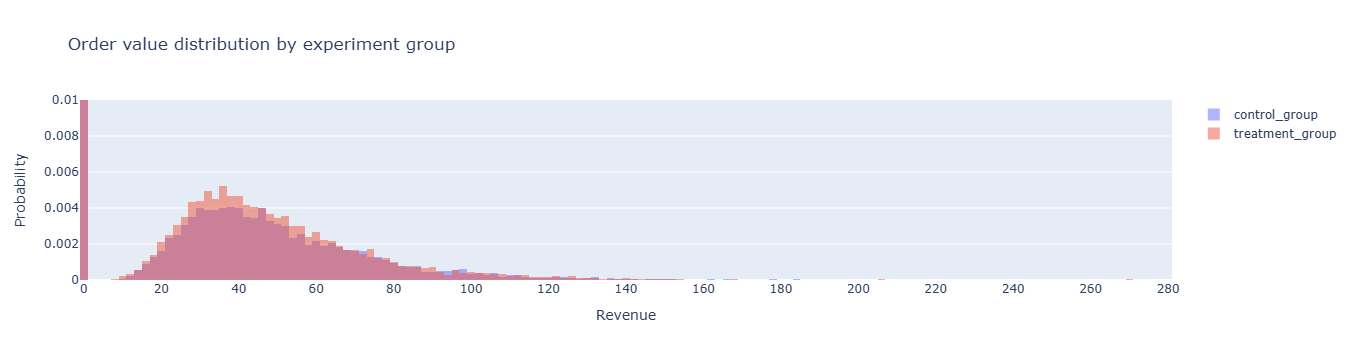

In [131]:
fig = go.Figure()

fig.add_trace(go.Histogram(x=control_value,
                           name='control_group',
                           histnorm='probability',
                           opacity=0.5,
                           nbinsx=200,
                          )
             )

fig.add_trace(go.Histogram(x=treatment_value,
                           name='treatment_group',
                           histnorm='probability',
                           opacity=0.5,
                           nbinsx=200,
                          )
             )

fig.update_layout(
    title="Order value distribution by experiment group",
    xaxis_title="Revenue",
    yaxis_title="Probability",
    barmode="overlay"
)

fig.update_yaxes(
    range=[0, 0.01]
)

fig.update_xaxes(
    dtick=20
)
fig.show()

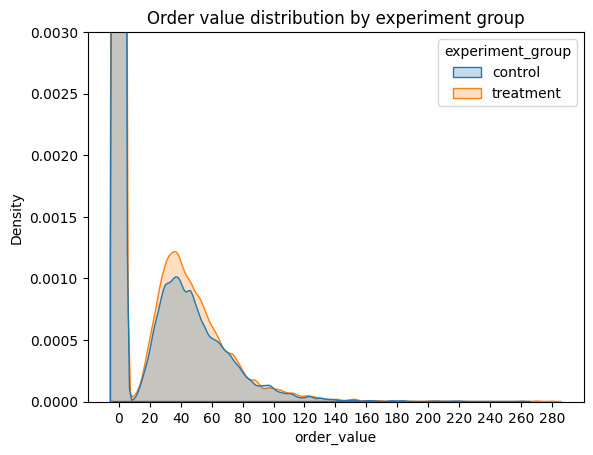

In [132]:
sns.kdeplot(data=df,
            x='order_value',
            hue='experiment_group',
            fill=True
           )
plt.title('Order value distribution by experiment group')
plt.ylim(0, 0.003)
plt.xticks(np.arange(0, 300, 20))
plt.show()

In [133]:
df_order_value = df[df['order_value']!=0]
df_order_value_by_group = df_order_value.groupby('experiment_group')['order_value'].sum()
order_value_control = df_order_value_by_group[0]
order_value_treatment = df_order_value_by_group[1]
order_value_lift = 100 * (order_value_treatment - order_value_control) / order_value_control
print(f'If only counting customers who order, lift of order value by group: {order_value_lift:.3f}%')

If only counting customers who order, lift of order value by group: 13.350%


**Observation**
- From T statistics and under 95% confidence level, there is a statisticall significant difference in order value between control group and treatment group
- From order value distribution, treatment group has higher amount of order value from 30 to 60 period
- If only counting customers who order, lift of order value by group: 13.350%

## Segment analysis (chi square test)
- chi square test is used to understand whether there is a dependency between 2 categorical factors
- Cramer's V is used to quantify strength of dependency

In [134]:
# Define a cramers_v function to quantify the dependency level

def cramers_v(chi2, table):
    """
    Used to quantify the dependency level

    parameters:
    chi2 -- calculated chi square value 
    table -- crosstable between categorical column and target column to correlated with

    return
    v -- Cramer's value
    """
    n = table.sum().sum()  # n = total sample
    k = min(table.shape)  # k = smaller dimension
    v = np.sqrt(chi2 / (n * (k - 1)))

    return v

In [135]:
dep_col_added_to_cart = []  # list to store columns with strong dependency
for col in ['device', 'traffic_source', 'customer_type', 'country']:
    # prepare cross table
    table = pd.crosstab(df[col], df['added_to_cart'])
    # print(table)
    # print('=' * 50)

    # dependency analysis
    chi2, p_value, dof, expected = chi2_contingency(table)
    v = cramers_v(chi2, table)

    print(f'Segment analysis: {col}')
    print(f'chi square: {chi2}')
    print(f'p-value: {p_value}')
    print(f"Cramer's v: {v:.3f}")
    # print(f'Degree of freedom: {dof}')
    # print(f'Expected frequency:\n {expected}')
    

    if p_value < 0.05 and v > 0.5:
        print(f'Strong dependency between {col} and added_to_cart')
        dep_col_added_to_cart.append(col)
    elif p_value < 0.05 and v <= 0.5:
        print(f'Weak dependency between {col} and added_to_cart')
    elif p_value >= 0.05:
        print(f'No dependency between {col} and added_to_cart')

    print('\n')
print(f'Factors have strong dependency with added_to_cart: {dep_col_added_to_cart}')

Segment analysis: device
chi square: 260.5129121011398
p-value: 2.693642185408595e-57
Cramer's v: 0.047
Weak dependency between device and added_to_cart


Segment analysis: traffic_source
chi square: 210.85901622924317
p-value: 1.7362347773082266e-44
Cramer's v: 0.042
Weak dependency between traffic_source and added_to_cart


Segment analysis: customer_type
chi square: 509.35825571818106
p-value: 8.746615102803224e-113
Cramer's v: 0.065
Weak dependency between customer_type and added_to_cart


Segment analysis: country
chi square: 2.926978115529412
p-value: 0.4030212798830547
Cramer's v: 0.005
No dependency between country and added_to_cart


Factors have strong dependency with added_to_cart: []


In [136]:
dep_col_started_checkout = []  # list to store columns with strong dependency
for col in ['device', 'traffic_source', 'customer_type', 'country']:
    # prepare cross table
    table = pd.crosstab(df[col], df['started_checkout'])
    # print(table)
    # print('=' * 50)

    # dependency analysis
    chi2, p_value, dof, expected = chi2_contingency(table)
    v = cramers_v(chi2, table)

    print(f'Segment analysis: {col}')
    print(f'chi square: {chi2}')
    print(f'p-value: {p_value}')
    print(f"Cramer's v: {v:.3f}")
    # print(f'Degree of freedom: {dof}')
    # print(f'Expected frequency:\n {expected}')
    

    if p_value < 0.05 and v > 0.5:
        print(f'Strong dependency between {col} and started_checkout')
        dep_col_started_checkout.append(col)
    elif p_value < 0.05 and v <= 0.5:
        print(f'Weak dependency between {col} and started_checkout')
    elif p_value >= 0.05:
        print(f'No dependency between {col} and started_checkout')

    print('\n')
print(f'Factors have strong dependency with started_checkout: {dep_col_started_checkout}')

Segment analysis: device
chi square: 459.2510249552472
p-value: 1.8832458833278878e-100
Cramer's v: 0.062
Weak dependency between device and started_checkout


Segment analysis: traffic_source
chi square: 105.11932367850078
p-value: 7.988527210916444e-22
Cramer's v: 0.030
Weak dependency between traffic_source and started_checkout


Segment analysis: customer_type
chi square: 271.30298564963107
p-value: 5.901082626102145e-61
Cramer's v: 0.048
Weak dependency between customer_type and started_checkout


Segment analysis: country
chi square: 1.7054184820410705
p-value: 0.6357298156662234
Cramer's v: 0.004
No dependency between country and started_checkout


Factors have strong dependency with started_checkout: []


In [137]:
dep_col_purchased = []  # list to store columns with strong dependency
for col in ['device', 'traffic_source', 'customer_type', 'country']:
    # prepare cross table
    table = pd.crosstab(df[col], df['purchased'])
    # print(table)
    # print('=' * 50)

    # dependency analysis
    chi2, p_value, dof, expected = chi2_contingency(table)
    v = cramers_v(chi2, table)
    
    print(f'Segment analysis: {col}')
    print(f'chi square: {chi2}')
    print(f'p-value: {p_value}')
    print(f"Cramer's v: {v:.3f}")
    # print(f'Degree of freedom: {dof}')
    # print(f'Expected frequency:\n {expected}')
    

    if p_value < 0.05 and v > 0.5:
        print(f'Strong dependency between {col} and purchased')
        dep_col_purchased.append(col)
    elif p_value < 0.05 and v <= 0.5:
        print(f'Weak dependency between {col} and purchased')
    elif p_value >= 0.05:
        print(f'No dependency between {col} and purchased')
    elif p_value < 0.05 and v <= 0.5:
        print(f'Weak dependency between {col} and purchased')
    print('\n')
print(f'Factors have strong dependency with purchased: {dep_col_purchased}')

Segment analysis: device
chi square: 524.6992608555286
p-value: 1.1561206965230419e-114
Cramer's v: 0.066
Weak dependency between device and purchased


Segment analysis: traffic_source
chi square: 121.88385739153722
p-value: 2.114664014048045e-25
Cramer's v: 0.032
Weak dependency between traffic_source and purchased


Segment analysis: customer_type
chi square: 295.7031782390667
p-value: 2.843978447030291e-66
Cramer's v: 0.050
Weak dependency between customer_type and purchased


Segment analysis: country
chi square: 2.765512898687833
p-value: 0.42920861797847576
Cramer's v: 0.005
No dependency between country and purchased


Factors have strong dependency with purchased: []


**Observation**
- With chi square and under 95% confidence level, device, traffic_source, and customer_type have a dependency with target columns (added_to_cart, start_checkout, and purchased)
- With Crame's V to quantify the level of dependency, none of device, traffic_source, and customer_type shows strong dependency

## Conversion rate analysis (z test)
- Z test is used to understand whether there is a statistically significant difference in conversion rate between control group and treatment group

In [138]:
steps = ['added_to_cart', 'started_checkout', 'purchased']
for step in steps:
    print(f'At {step} step')
    
    # calculate total sample number and success number
    num_control = df[df['experiment_group']=='control'][step].count()
    success_control = df[df['experiment_group']=='control'][step].sum()
    num_treatment = df[df['experiment_group']=='treatment'][step].count()
    success_treatment = df[df['experiment_group']=='treatment'][step].sum()
    print(f'Total number of control group: {num_control}')
    print(f'Success number of control group: {success_control}')
    print(f'Total number of treatment group: {num_treatment}')
    print(f'Success number of treatment group: {success_treatment}')
    print('\n')

    # Z test
    successes = [success_treatment, success_control]
    nobs = [num_treatment, num_control]
    z_stats, p_value = proportions_ztest(count=successes,  # number of success (treatment_group, control_group)
                                         nobs=nobs,  # total sample number at each group (treatment_group, control_group)
                                         alternative='larger'
                                        )

    print(f'Z score at {step}: {z_stats}')
    print(f'p value at {step}: {p_value}')
    if p_value < 0.05:
        print(f'There is statistically signifincant difference between control and treatement at {step}')
    else:
        print(f'There is no statistically signifincant difference between control and treatement at {step}')
    print('=' * 100)

At added_to_cart step
Total number of control group: 59888
Success number of control group: 20648
Total number of treatment group: 60112
Success number of treatment group: 20734


Z score at added_to_cart: 0.05316322804369359
p value at added_to_cart: 0.47880092696595594
There is no statistically signifincant difference between control and treatement at added_to_cart
At started_checkout step
Total number of control group: 59888
Success number of control group: 12529
Total number of treatment group: 60112
Success number of treatment group: 13379


Z score at started_checkout: 5.624405160877613
p value at started_checkout: 9.307414354400322e-09
There is statistically signifincant difference between control and treatement at started_checkout
At purchased step
Total number of control group: 59888
Success number of control group: 5626
Total number of treatment group: 60112
Success number of treatment group: 6485


Z score at purchased: 8.015360856086328
p value at purchased: 5.4907061459163

**Observation**
- At 95% confidence level, there is a statistically significant difference at started_checkout and purchased between control group and treamtment group
- It also concludes that the relative lift at started_checkout and purchased is significant

## Final business decision

### Conclusion summary
- Lift analysis: 6.386% relative lift at started_checkout and 14.839% relative lift at purchased
- Funnel analysis: Modified checkout process affects customer behavior at started_checkout (1.3% delta) and purchased step (1.4% delta)
- Revenue analysis:
  - Significant difference in order value with 95% confidence level
  - Higher distribution of order value at 30~60 region at treatement group
  - Considering customers who order, lift of order value by group is 13.35%
- Segment analysis
  - No strong dependency between categorical factors and target columns with 95% confidence level and Camer's V analysis
- Conversion analysis: Significant difference at started_checkout and purchased with 95% confidence

### Final busincess decision
- Observed siginificant improvement in lift and conversion rate gain. As a result, it reflects at the significant revenue gain
- Based on pov of significant gain above, suggest to roll out the modified checkout process
- Other open questions might affect final business decision
  - Man power perspective. How much resource is needed to roll out the process ?
  - Cost perspective. How much is the cost to roll out the process 